In [1]:
import pandas as pd
import numpy as np

In [2]:
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.preprocessing import KBinsDiscretizer
from sklearn.compose import ColumnTransformer

### KbinsDiscretizers takes the three params:
#### 1.No of bins
#### 2.Strategy: uniform, quantile, kmeans( which binning techniques to use : equal width/ uniform , quantile/equal frequency, Kmeans clustering)
#### 3.Encoding: Ordinal, One hot encoding 

In [3]:
df = pd.read_csv('../../train.csv',usecols=['Age','Fare','Survived'])

In [5]:
df.dropna(inplace=True)

In [6]:
df.shape

(714, 3)

In [7]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [8]:
X = df.iloc[:,1:]
y = df.iloc[:,0]

In [9]:

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [10]:
X_train.head(2)

,Age,Fare
328,31.0,20.5250
73,26.0,14.4542


In [13]:

clf = DecisionTreeClassifier()

In [14]:
clf.fit(X_train,y_train)
y_pred = clf.predict(X_test)

In [15]:

accuracy_score(y_test,y_pred)

0.6293706293706294

In [16]:
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6317097026604068)

## Using the Quantile Binning: 

In [17]:
kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')
kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='quantile')

For using the uniform we can do this.

In [ ]:
# kbin_age = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='uniform')
# kbin_fare = KBinsDiscretizer(n_bins=15,encode='ordinal',strategy='uniform')

In [18]:
trf = ColumnTransformer([
    ('first',kbin_age,[0]),
    ('second',kbin_fare,[1])
])

In [19]:
X_train_trf = trf.fit_transform(X_train)
X_test_trf = trf.transform(X_test)

After tranformation 

In [ ]:
trf.named_transformers_
trf.named_transformers_['first'].n_bins_

{'first': KBinsDiscretizer(encode='ordinal', n_bins=15),
 'second': KBinsDiscretizer(encode='ordinal', n_bins=15)}

Edges or range of the bins created

In [21]:
trf.named_transformers_['first'].bin_edges_

array([array([ 0.42,  6.  , 16.  , 19.  , 21.  , 23.  , 25.  , 28.  , 30.  ,
              32.  , 35.  , 38.  , 42.  , 47.  , 54.  , 80.  ])             ],
      dtype=object)

In [22]:
output = pd.DataFrame({
    'age':X_train['Age'],
    'age_trf':X_train_trf[:,0],
    'fare':X_train['Fare'],
    'fare_trf':X_train_trf[:,1]
})

In [23]:
output['age_labels'] = pd.cut(x=X_train['Age'],
                                    bins=trf.named_transformers_['first'].bin_edges_[0].tolist())
output['fare_labels'] = pd.cut(x=X_train['Fare'],
                                    bins=trf.named_transformers_['second'].bin_edges_[0].tolist())



In [24]:
output.sample(5)

,age,age_trf,fare,fare_trf,age_labels,fare_labels
871,47.0,13.0,52.5542,12.0,"(42.0, 47.0]","(51.479, 76.292]"
881,33.0,9.0,7.8958,3.0,"(32.0, 35.0]","(7.775, 7.896]"
834,18.0,2.0,8.3000,4.0,"(16.0, 19.0]","(8.158, 10.5]"
830,15.0,1.0,14.4542,7.0,"(6.0, 16.0]","(13.0, 14.454]"
848,28.0,7.0,33.0000,11.0,"(25.0, 28.0]","(31.275, 51.479]"


In [25]:
clf = DecisionTreeClassifier()
clf.fit(X_train_trf,y_train)
y_pred2 = clf.predict(X_test_trf)

In [26]:
accuracy_score(y_test,y_pred2)

0.6363636363636364

In [27]:
X_trf = trf.fit_transform(X)
np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy'))

np.float64(0.6358568075117371)

### Functions to use different strategy

In [28]:
def discretize(bins,strategy):
    kbin_age = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    kbin_fare = KBinsDiscretizer(n_bins=bins,encode='ordinal',strategy=strategy)
    
    trf = ColumnTransformer([
        ('first',kbin_age,[0]),
        ('second',kbin_fare,[1])
    ])
    
    X_trf = trf.fit_transform(X)
    print(np.mean(cross_val_score(DecisionTreeClassifier(),X,y,cv=10,scoring='accuracy')))
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Age'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,0],color='red')
    plt.title("After")

    plt.show()
    
    plt.figure(figsize=(14,4))
    plt.subplot(121)
    plt.hist(X['Fare'])
    plt.title("Before")

    plt.subplot(122)
    plt.hist(X_trf[:,1],color='red')
    plt.title("Fare")

    plt.show()
    

#### Using the different binning algorithms

0.6316901408450704


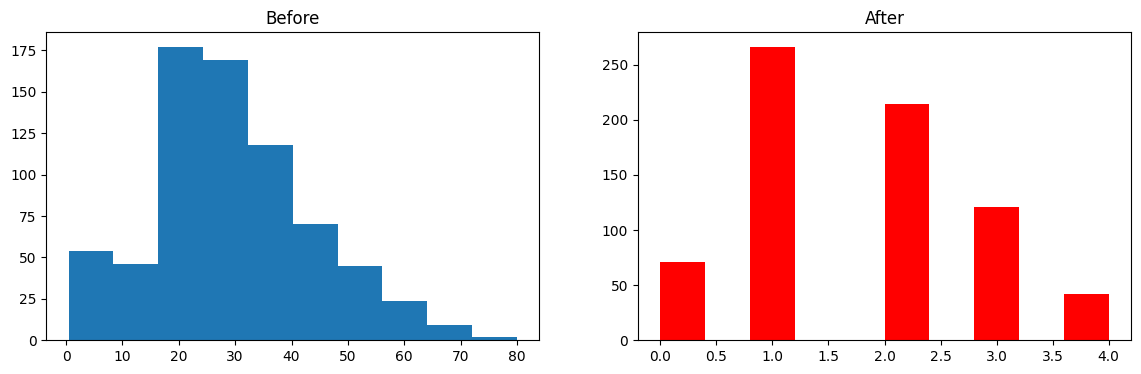

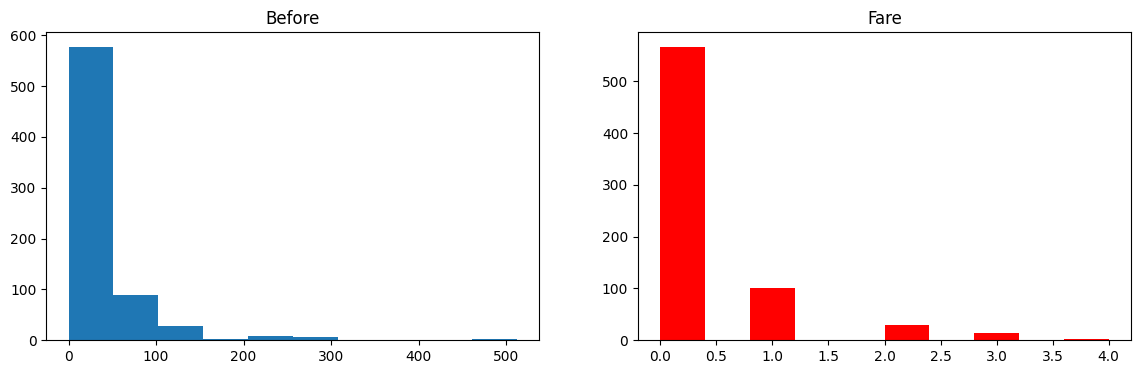

In [29]:
discretize(5,'kmeans')

0.6330985915492958


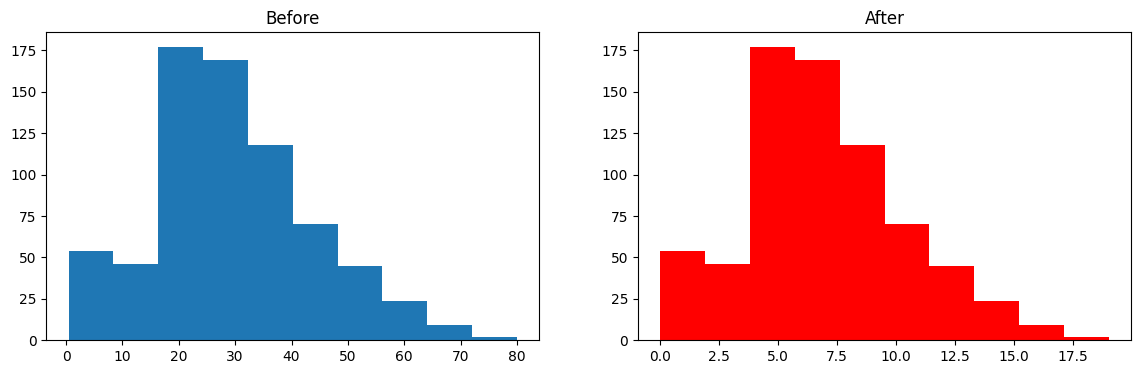

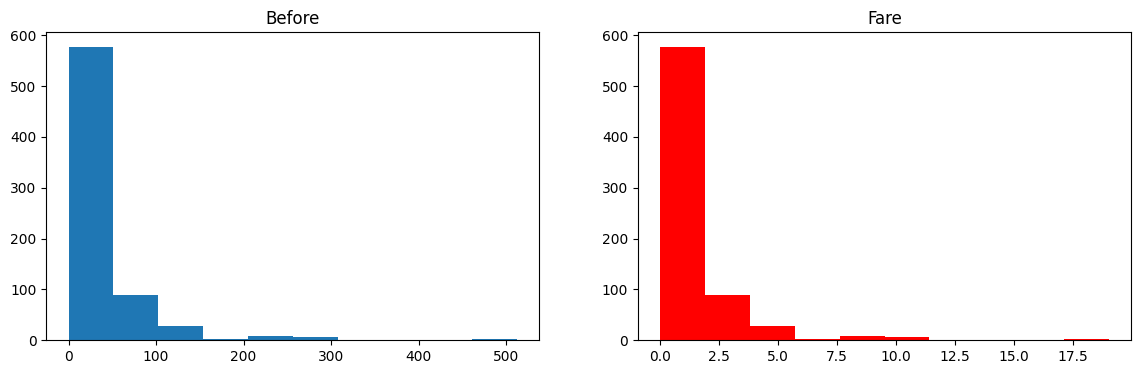

In [35]:
discretize(20,'uniform')


0.6260954616588419


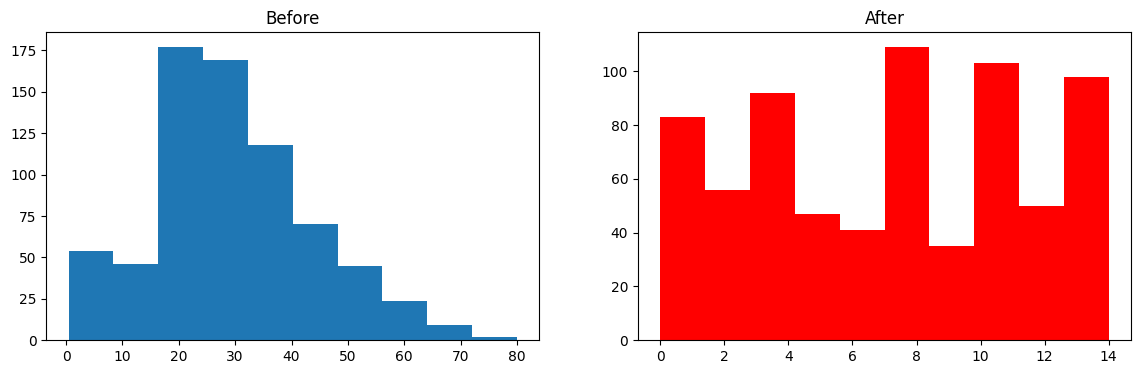

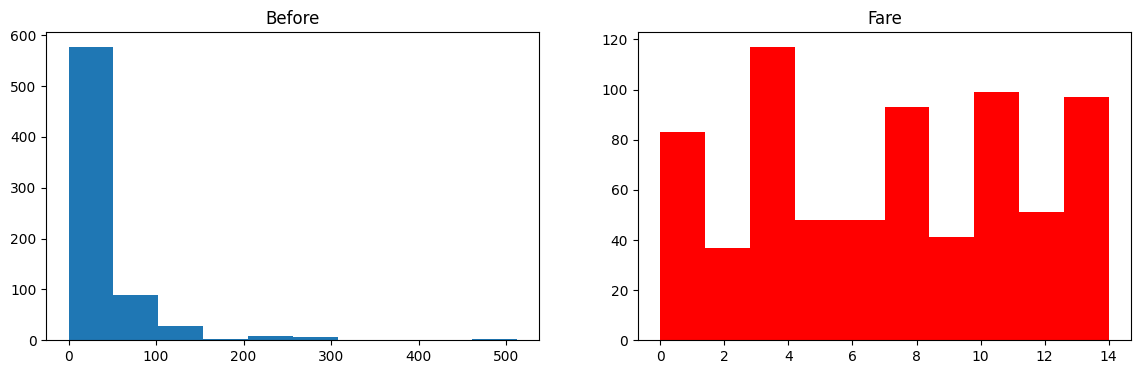

In [39]:
discretize(15,'quantile')


We can use the custom binning as per our domains needs. We need to use the pandas dataframe logic for that purpose Sklearn doesnot have the builtin support for other than these 3 strategies 